# Constructing Full-Field Brightness Stimuli for Testing

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import imageProc as pr

sns.set_context('talk')
%matplotlib inline
from stimGen import generateSingleSpotPan, plotPanorama, plotPanoramaStretch, createMovie

In [2]:
screenMinDist = 4.0 #cm (r_min in Fig1 S1)
screenMaxDist = 5.5 #cm (r_max in Fig1 S1)

topScreenHeight = 2.5 #cm
bottomScreenHeight = 7 #cm

alpha_rmin = (180/np.pi) * np.arctan( topScreenHeight / screenMinDist)
alpha_rmax = (180/np.pi) * np.arctan( topScreenHeight / screenMaxDist)

print("The screen spans an angle from {} to {} above the horizon line.".format(alpha_rmax, alpha_rmin))

The screen spans an angle from 24.443954780416536 to 32.005383208083494 above the horizon line.


Set `no-ball` to `True` so you can generate appropriate sized scenes

In [3]:
no_ball = True

In [4]:
if not no_ball:
    ballRad = 4.65 # treadmill ball radius [mm]
    flyEyeAboveBall = 1 # height of eye above ball surface [mm]
    print('Angle visible below horizon line:',90-(180/np.pi)*np.arcsin(ballRad/(flyEyeAboveBall+ballRad)))
else:
    beta_rmin = (180/np.pi) * np.arctan( bottomScreenHeight / screenMinDist)
    beta_rmax = (180/np.pi) * np.arctan( bottomScreenHeight / screenMaxDist)
    print("The screen spans an angle from {} to {} below the horizon line.".format(beta_rmax, beta_rmin))

The screen spans an angle from 51.84277341263094 to 60.25511870305777 below the horizon line.


## Generating Brightness Values

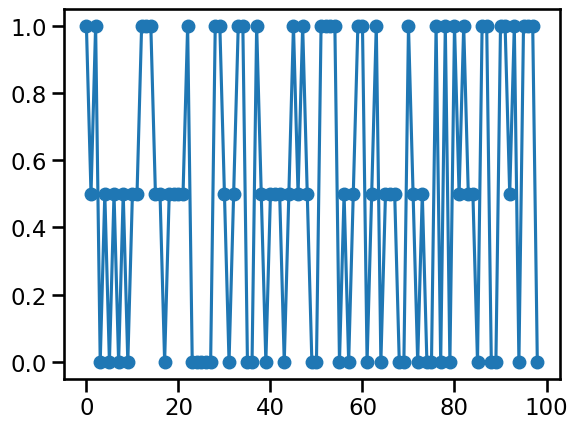

In [48]:
Nimages = 100
n_levels = 3
seed = 42
np.random.seed(seed)
brightness_series = np.random.permutation(np.array(list(np.linspace(0,1,n_levels))*(int(np.round((Nimages/n_levels))))))
plt.plot(brightness_series, 'o-');

## Add Stimuli

In [44]:
visibility = 1 #in m
hfovDeg = 288 #deg
resDeg = 0.1 #deg
upDeg = alpha_rmax #deg
downDeg = -beta_rmax #deg

In [58]:
hfov = hfovDeg*np.pi/180
up = upDeg*np.pi/180
down = downDeg*np.pi/180
res = resDeg*np.pi/180
vfov = up-down
scenes = np.ones((int(n_levels*np.round((Nimages/n_levels))), int(hfov/res), int(vfov/res))).T*brightness_series[np.newaxis, np.newaxis, :]

In [59]:
stimuliSet = scenes.copy()

maxBit = 255
stimuliSet = (stimuliSet*maxBit).astype(np.uint8)

In [60]:
%%capture
anim = createMovie(stimuliSet.T,scenes.shape[0],scenes.shape[1],maxBit)

In [61]:
from IPython.display import HTML
HTML(anim.to_jshtml())

## Save movie as a series of images

In [62]:
seperatorDuration = 0 #seconds
frameDuration = 4 #seconds
repeats = 1 #how many times to repeat the full set of stimuli

In [71]:
video_name = "fullFieldFlash_nScenes-"+str(scenes.shape[2])+"_seperatorDur-"+str(
    seperatorDuration)+"_frameDur-"+str(frameDuration)+"_seed-"+str(seed)+"_nLevels-"+str(n_levels)+"_repeats-"+str(repeats)

In [72]:
import pandas as pd

In [73]:
imageDf = pd.DataFrame({
    'filename': [f"frame_{i:03d}.png" for i in range(np.shape(stimuliSet)[2])],
    'repeat': [repeats for i in range(np.shape(stimuliSet)[2])],
    'brightness': brightness_series
})

In [74]:
from os import sep
from pathlib import Path
Path(sep.join(["movies",video_name])).mkdir(parents=True, exist_ok=True)

In [75]:
import imageio
textures = []
for i in range(len(imageDf)):
    imageio.imwrite(sep.join(["movies",video_name,imageDf.iloc[i]['filename']]), np.flip(stimuliSet[:,:,i], axis=0))
    textures.append(imageDf.iloc[i]['filename'])



In [76]:
import json
temp = {
    'durationSecs': frameDuration+seperatorDuration,
    'textures': textures*repeats,
    'separatorDurationSecs': seperatorDuration,
}
json_name = sep.join(["movies",video_name,'start.json'])
with open(json_name, 'w') as json_file:
    json_file.write(json.dumps(temp))